In [2]:
import jax
import jax.numpy as jnp
import numpy as np
import optax

from pyscf import ao2mo, gto, scf, fci
import matplotlib.pyplot as plt

from libdet import Hamiltonian
from detnqs.model import Backflow, RBM
from detnqs.vstate import SelectedState, ExactState
from detnqs.driver import VMC
from detnqs.optimizer import sr, minsr, adamsr
from detnqs import utils

utils.batch.configure(chunk=8192)
utils.precision.configure("double")
jax.config.update("jax_debug_nans", False)
jax.config.update("jax_log_compiles", False)

def hf_det(n_alpha: int, n_beta: int, *, nword: int = 1) -> np.ndarray:
    det = np.zeros((1, 2, nword), dtype=np.uint64)
    for i in range(n_alpha):
        det[0, 0, i >> 6] |= np.uint64(1) << np.uint64(i & 63)
    for i in range(n_beta):
        det[0, 1, i >> 6] |= np.uint64(1) << np.uint64(i & 63)
    return det

def plot_convergence(history, e_fci):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
    step = np.arange(len(history))

    ax = axes[0]
    ax.plot(step, history, linewidth=1.4)
    ax.axhline(e_fci, linestyle="--", linewidth=1.2)
    ax.set_xlabel("Step")
    ax.set_ylabel("Energy (Hartree)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    ax = axes[1]
    ax.semilogy(step, np.abs(np.asarray(history) - e_fci), linewidth=1.4)
    ax.set_xlabel("Step")
    ax.set_ylabel("|E - E_FCI| (Hartree)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    return fig, axes

In [3]:
mol = gto.M(
    atom=
    '''
    O   0.00000000,  0.00000000,  0.00000000
    H   0.75700000,  0.00000000,  0.58590000
    H  -0.75700000,  0.00000000,  0.58590000
    ''',
    basis="sto-3g",
    unit="Angstrom",
    verbose=0,
)
mf = scf.RHF(mol).run()
norb = mf.mo_coeff.shape[1]
n_alpha, n_beta = mol.nelec

# Canonical MO
h1e = np.asarray(mf.mo_coeff.T @ mf.get_hcore() @ mf.mo_coeff, dtype=np.float64)
eri = np.asarray(ao2mo.restore(8, ao2mo.kernel(mol, mf.mo_coeff), norb), dtype=np.float64)

ham = Hamiltonian.rhf(h1e, eri, ecore=mol.energy_nuc())

solver = fci.direct_spin0.FCI(mol)
e_fci, ci = solver.kernel(h1e, eri, norb, mol.nelec, ecore=mol.energy_nuc())
s2, mult = fci.spin_op.spin_square(ci, norb, mol.nelec)

print(f"SCF energy : {mf.e_tot:.12f}")
print(f"FCI energy : {e_fci:.12f}")
print(f"S^2  : {s2:.6f}")

model = Backflow(norb=norb, n_alpha=n_alpha, n_beta=n_beta, hidden=(64,))
# model = RBM(norb=norb, alpha=1)

SCF energy : -74.962934879059
FCI energy : -75.012416346077
S^2  : 0.000000


E0524 20:15:00.018129  100955 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0524 20:15:00.027925  100768 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


step= 0  energy=-74.961913043311
step=50  energy=-75.012409064581
step=100  energy=-75.012415250229
step=150  energy=-75.012415900949
step=200  energy=-75.012416082166
step=250  energy=-75.012416158785
step=300  energy=-75.012416201357
step=350  energy=-75.012416228741
step=400  energy=-75.012416247829
step=450  energy=-75.012416261832
step=499  energy=-75.012416272300


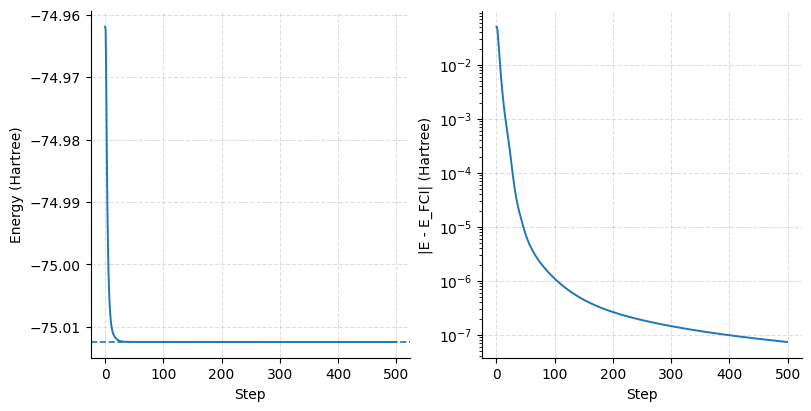

In [4]:
state = ExactState.init(
    model=model,
    hamiltonian=ham,
    n_alpha=n_alpha,
    n_beta=n_beta,
    key=jax.random.key(0),
)

optimizer = optax.chain(
    adamsr(shift=1e-2),
    optax.scale(-5e-2)
)

vmc = VMC.init(state, optimizer)

history = []
steps = 500

for step in range(steps):
    history.append(vmc.step()["energy"]) 
    state = vmc.state
    if step % 50 == 0 or step == steps - 1:
        print(f"step={step:2d}  energy={history[-1]:.12f}")
    
plot_convergence(history, e_fci)
plt.show()

outer= 0  energy=-75.011472237476  |V|=  41
outer= 1  energy=-75.012401396516  |V|= 128
outer= 2  energy=-75.012416033020  |V|= 128
outer= 3  energy=-75.012416145049  |V|= 128
outer= 4  energy=-75.012416199251  |V|= 128


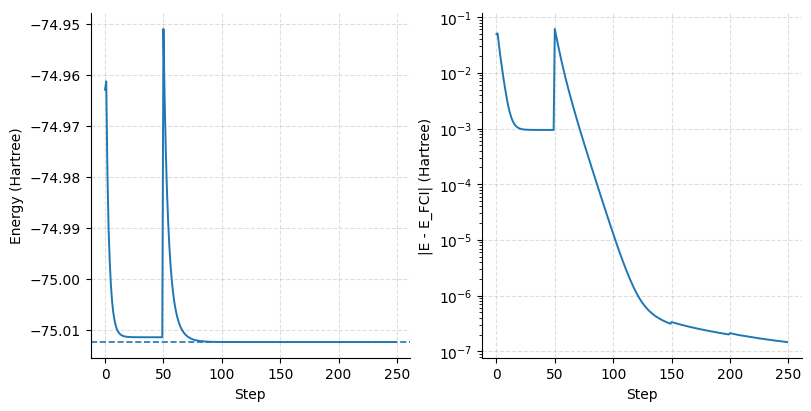

In [5]:
from detnqs.vstate.selected import topk_selector

state = SelectedState.init(
    model=model,
    hamiltonian=ham,
    init_v=hf_det(n_alpha, n_beta),
    key=jax.random.key(0),
)

optimizer = optax.chain(
    adamsr(shift=1e-2),
    optax.scale(-5e-2)
)

vmc = VMC.init(state, optimizer)

history   = []
outer_steps = 5
inner_steps = 50

for outer in range(outer_steps):
    selector = topk_selector(k=128)
    state = state.evolve(selector, eps=1e-6)
    vmc.state = state

    for _ in range(inner_steps):
        history.append(vmc.step()["energy"])

    state = vmc.state
    print(f"outer={outer:2d}  energy={history[-1]:.12f}  |V|={state.n_v:4d}")
    
plot_convergence(history, e_fci)
plt.show()